# Multivariate Analysis

## 1. load cleaned Sustainable living Quality index dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
slqi_dataset = pd.read_csv("../Dataset/final_SLQI_dataset.csv")
slqi_dataset.head()

,Country,Country Code,gdp_per_capita,inflation,unemployment_rate,life_expectancy,secondary_enrollment,electricity_access,drinking_water_access,sanitation_access,government_effectiveness,political_stability,rule_of_law,forest_area,pm25_exposure,renewable_energy
0,Afghanistan,AFG,413.757895,-6.601186,13.6870,66.289,59.613602,85.3,80.832437,54.495799,-1.933997,-2.205211,-1.935489,1.852782,46.087094,20.0
1,Albania,ALB,11377.775743,2.215874,10.6890,79.776,108.355392,100.0,95.119427,99.299715,0.312344,0.020467,-0.118502,28.791971,15.707004,41.9
2,Algeria,DZA,5752.990767,4.046115,11.6550,76.475,105.164132,100.0,92.420029,85.906486,-0.251191,-0.693588,-0.696777,0.830314,25.552656,0.1
3,American Samoa,ASM,18017.458938,3.117464,5.1895,72.992,92.659564,100.0,100.000000,62.119698,0.767382,1.253029,1.086581,85.200000,6.715147,0.4
4,Andorra,AND,49303.649167,3.117464,5.1895,84.188,101.923820,100.0,100.000000,100.000000,1.159037,1.543796,1.409905,34.042553,9.080281,18.7


## 2. Check basic information

In [3]:
slqi_dataset.shape
slqi_dataset.info()
slqi_dataset.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 206 entries, 0 to 205
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Country                   206 non-null    str    
 1   Country Code              206 non-null    str    
 2   gdp_per_capita            206 non-null    float64
 3   inflation                 206 non-null    float64
 4   unemployment_rate         206 non-null    float64
 5   life_expectancy           206 non-null    float64
 6   secondary_enrollment      206 non-null    float64
 7   electricity_access        206 non-null    float64
 8   drinking_water_access     206 non-null    float64
 9   sanitation_access         206 non-null    float64
 10  government_effectiveness  206 non-null    float64
 11  political_stability       206 non-null    float64
 12  rule_of_law               206 non-null    float64
 13  forest_area               206 non-null    float64
 14  pm25_exposure        

Country                     0
Country Code                0
gdp_per_capita              0
inflation                   0
unemployment_rate           0
life_expectancy             0
secondary_enrollment        0
electricity_access          0
drinking_water_access       0
sanitation_access           0
government_effectiveness    0
political_stability         0
rule_of_law                 0
forest_area                 0
pm25_exposure               0
renewable_energy            0
dtype: int64

In [4]:
indicator_cols = [
    "gdp_per_capita",
    "inflation",
    "unemployment_rate",
    "life_expectancy",
    "secondary_enrollment",
    "electricity_access",
    "drinking_water_access",
    "sanitation_access",
    "government_effectiveness",
    "political_stability",
    "rule_of_law",
    "forest_area",
    "pm25_exposure",
    "renewable_energy"
]

In [5]:
slqi_dataset[indicator_cols].describe()

,gdp_per_capita,inflation,unemployment_rate,life_expectancy,secondary_enrollment,electricity_access,drinking_water_access,sanitation_access,government_effectiveness,political_stability,rule_of_law,forest_area,pm25_exposure,renewable_energy
count,206.000000,206.000000,206.000000,206.000000,206.000000,206.000000,206.000000,206.000000,206.000000,206.000000,206.000000,206.000000,206.000000,206.000000
mean,21921.118678,7.937567,6.729267,73.717081,89.381236,87.665534,90.874102,81.253817,0.049222,-0.024762,-0.046080,32.470867,23.481144,30.031068
std,34372.211703,21.449114,5.370782,7.151911,24.272111,22.778118,13.582216,25.154985,0.966541,0.997872,1.013672,23.977237,14.754352,27.121666
min,219.424831,-12.296984,0.130000,54.635000,3.347850,5.400000,35.681361,10.357719,-2.172846,-2.750564,-2.205450,0.000000,4.895181,0.000000
25%,2757.805057,2.075134,3.410250,68.493000,84.528188,87.100000,88.182551,71.941009,-0.680011,-0.616041,-0.866880,11.536493,12.496784,8.825000
50%,8074.625991,3.117464,5.189500,74.173671,92.659564,100.000000,97.096571,92.991282,0.010027,0.015964,-0.144347,32.433058,20.028714,21.150000
75%,29272.479658,4.675934,8.373250,78.968817,101.836309,100.000000,99.760217,98.972923,0.704820,0.787683,0.718952,49.725946,29.434042,47.400000
max,288001.433369,219.883929,34.643000,86.497000,158.546616,100.000000,100.000000,100.000000,2.279627,1.582354,2.021270,94.447584,85.122346,96.300000


In [6]:
correlation_matrix = slqi_dataset[indicator_cols].corr()
correlation_matrix

,gdp_per_capita,inflation,unemployment_rate,life_expectancy,secondary_enrollment,electricity_access,drinking_water_access,sanitation_access,government_effectiveness,political_stability,rule_of_law,forest_area,pm25_exposure,renewable_energy
gdp_per_capita,1.000000,-0.118262,-0.145076,0.598001,0.449909,0.311035,0.356098,0.371692,0.675757,0.450677,0.612707,-0.070351,-0.327148,-0.218307
inflation,-0.118262,1.000000,0.071863,-0.170809,0.002798,-0.178113,-0.209941,-0.158958,-0.224612,-0.230758,-0.224963,-0.117152,0.080804,0.098381
unemployment_rate,-0.145076,0.071863,1.000000,-0.145402,0.064060,-0.028451,-0.000884,0.021423,-0.222189,-0.185499,-0.171280,-0.092022,-0.027503,-0.016114
life_expectancy,0.598001,-0.170809,-0.145402,1.000000,0.574500,0.721512,0.734911,0.784042,0.761482,0.534350,0.671874,0.009228,-0.456745,-0.539785
secondary_enrollment,0.449909,0.002798,0.064060,0.574500,1.000000,0.520646,0.487283,0.496893,0.538617,0.452968,0.540095,0.050649,-0.450754,-0.419954
electricity_access,0.311035,-0.178113,-0.028451,0.721512,0.520646,1.000000,0.872802,0.838274,0.566875,0.499920,0.505878,0.056009,-0.446821,-0.666559
drinking_water_access,0.356098,-0.209941,-0.000884,0.734911,0.487283,0.872802,1.000000,0.887531,0.581103,0.542997,0.530382,0.077962,-0.416608,-0.666934
sanitation_access,0.371692,-0.158958,0.021423,0.784042,0.496893,0.838274,0.887531,1.000000,0.575439,0.480879,0.488823,0.042646,-0.453565,-0.677503
government_effectiveness,0.675757,-0.224612,-0.222189,0.761482,0.538617,0.566875,0.581103,0.575439,1.000000,0.691773,0.901283,0.061936,-0.438648,-0.384267
political_stability,0.450677,-0.230758,-0.185499,0.534350,0.452968,0.499920,0.542997,0.480879,0.691773,1.000000,0.804323,0.308178,-0.504680,-0.393762


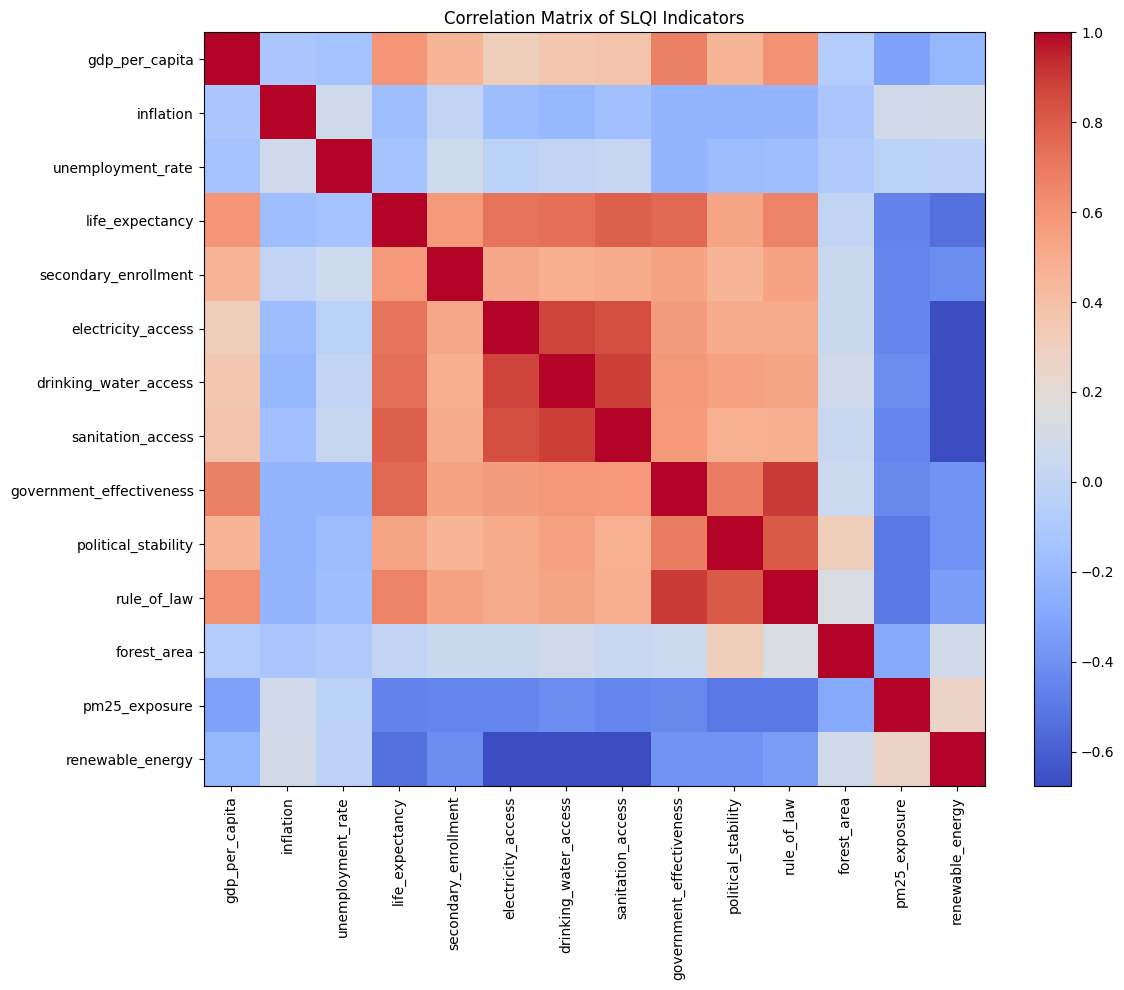

In [7]:
plt.figure(figsize=(12, 10))
plt.imshow(correlation_matrix, cmap="coolwarm", aspect="auto")
plt.colorbar()

plt.xticks(range(len(indicator_cols)), indicator_cols, rotation=90)
plt.yticks(range(len(indicator_cols)), indicator_cols)

plt.title("Correlation Matrix of SLQI Indicators")
plt.tight_layout()
plt.show()